In [10]:
# ============================================================
# PHASE 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Model saving
import joblib


# ============================================================
# DATASET LOCATION
# ============================================================

data_folder = Path(
    r"C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset"
)

print("Dataset folder:")
print(data_folder)


# ============================================================
# FIND EXCEL FILE
# ============================================================

excel_files = list(data_folder.glob("*.xlsx"))

print("\nExcel files found:")

for file in excel_files:
    print(file.name)


# Check whether Excel file exists
if len(excel_files) == 0:
    raise FileNotFoundError(
        "No .xlsx file was found in the Dataset folder."
    )


# ============================================================
# LOAD FIRST EXCEL FILE
# ============================================================

data_path = excel_files[0]

df = pd.read_excel(data_path)


# ============================================================
# BASIC INFORMATION
# ============================================================

print("\nDataset loaded successfully!")

print("\nDataset file:")
print(data_path.name)

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset folder:
C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset

Excel files found:
Dry_Bean_Cleaned.xlsx
Dry_Bean_Dataset.xlsx

Dataset loaded successfully!

Dataset file:
Dry_Bean_Cleaned.xlsx

Dataset shape:
(13543, 17)

Column names:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

First 5 rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


DATASET INFORMATION

Dataset Shape:
(13543, 17)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 13543 entries, 0 to 13542
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16 

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733



Missing Values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total Missing Values:
0

Number of Duplicate Rows:
0

No duplicate rows found.

Target Column:
Class

Unique Bean Classes:
<ArrowStringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

Number of Bean Classes:
7

Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


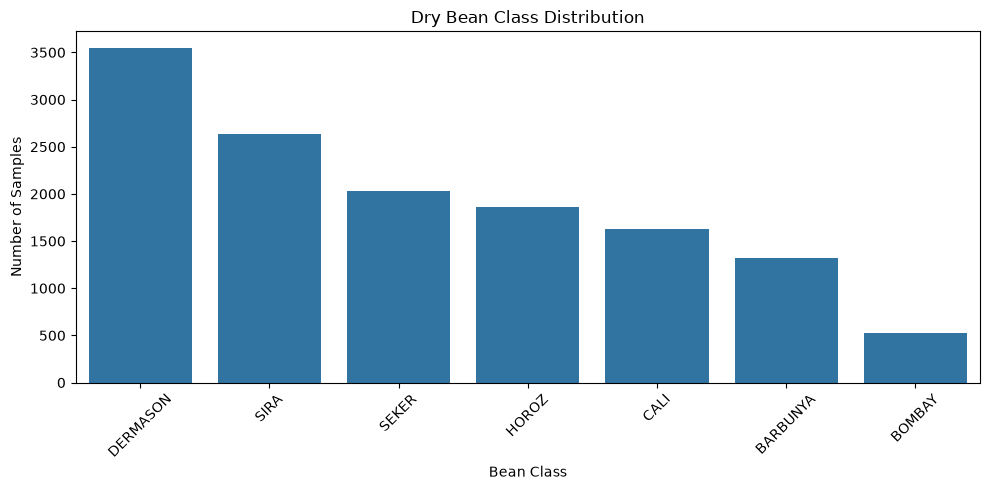


Cleaned dataset saved successfully:
C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\Dry_Bean_Cleaned.xlsx


In [11]:
# ============================================================
# PHASE 2: DATA UNDERSTANDING AND CLEANING
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

# Dataset shape
print("\nDataset Shape:")
print(df.shape)


# Data types and information
print("\nDataset Information:")
df.info()


# Statistical summary
print("\nStatistical Summary:")
display(df.describe())


# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


# Duplicate records
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# REMOVE DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

if duplicate_count > 0:

    df = df.drop_duplicates()

    df = df.reset_index(drop=True)

    print("\nDuplicates removed:", duplicate_count)

else:

    print("\nNo duplicate rows found.")


# ============================================================
# CHECK TARGET COLUMN
# ============================================================

print("\nTarget Column:")
print("Class")


# Unique classes
print("\nUnique Bean Classes:")
print(df["Class"].unique())


# Number of classes
print("\nNumber of Bean Classes:")
print(df["Class"].nunique())


# Class distribution
print("\nClass Distribution:")
print(df["Class"].value_counts())


# ============================================================
# CLASS DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Dry Bean Class Distribution")

plt.xlabel("Bean Class")

plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================================
# SAVE CLEANED DATASET
# ============================================================

cleaned_path = data_folder / "Dry_Bean_Cleaned.xlsx"

df.to_excel(
    cleaned_path,
    index=False
)

print("\nCleaned dataset saved successfully:")
print(cleaned_path)

EXPLORATORY DATA ANALYSIS

Number of numerical features:
16

Numerical features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Area,13543.0,53048.460385,29392.438324,20420.000000,36282.500000,44580.000000,61382.000000,254616.000000
Perimeter,13543.0,854.993406,214.722684,524.736000,703.230000,793.896000,977.146500,1985.370000
MajorAxisLength,13543.0,319.895602,85.809260,183.601165,253.086806,296.404589,376.312489,738.860153
MinorAxisLength,13543.0,202.365321,45.051632,122.512653,175.886357,192.491117,217.245403,460.198497
AspectRation,13543.0,1.581075,0.245245,1.024868,1.430662,1.549860,1.703916,2.430306
Eccentricity,13543.0,0.750315,0.091858,0.218951,0.715144,0.763997,0.809671,0.911423
ConvexArea,13543.0,53767.986709,29844.248525,20684.000000,36673.000000,45122.000000,62360.000000,263261.000000
EquivDiameter,13543.0,253.034094,59.307709,161.243764,214.933277,238.245711,279.560351,569.374358
Extent,13543.0,0.749829,0.048939,0.555315,0.718735,0.759903,0.786849,0.866195
Solidity,13543.0,0.987152,0.004650,0.919246,0.985678,0.988288,0.990019,0.994677



FEATURE SKEWNESS


,Feature,Skewness
0,Area,2.947136
6,ConvexArea,2.936102
15,ShapeFactor4,-2.760125
9,Solidity,-2.546877
3,MinorAxisLength,2.232013
7,EquivDiameter,1.947303
1,Perimeter,1.628018
2,MajorAxisLength,1.365813
5,Eccentricity,-1.064932
8,Extent,-0.895655



Generating feature distribution plots...


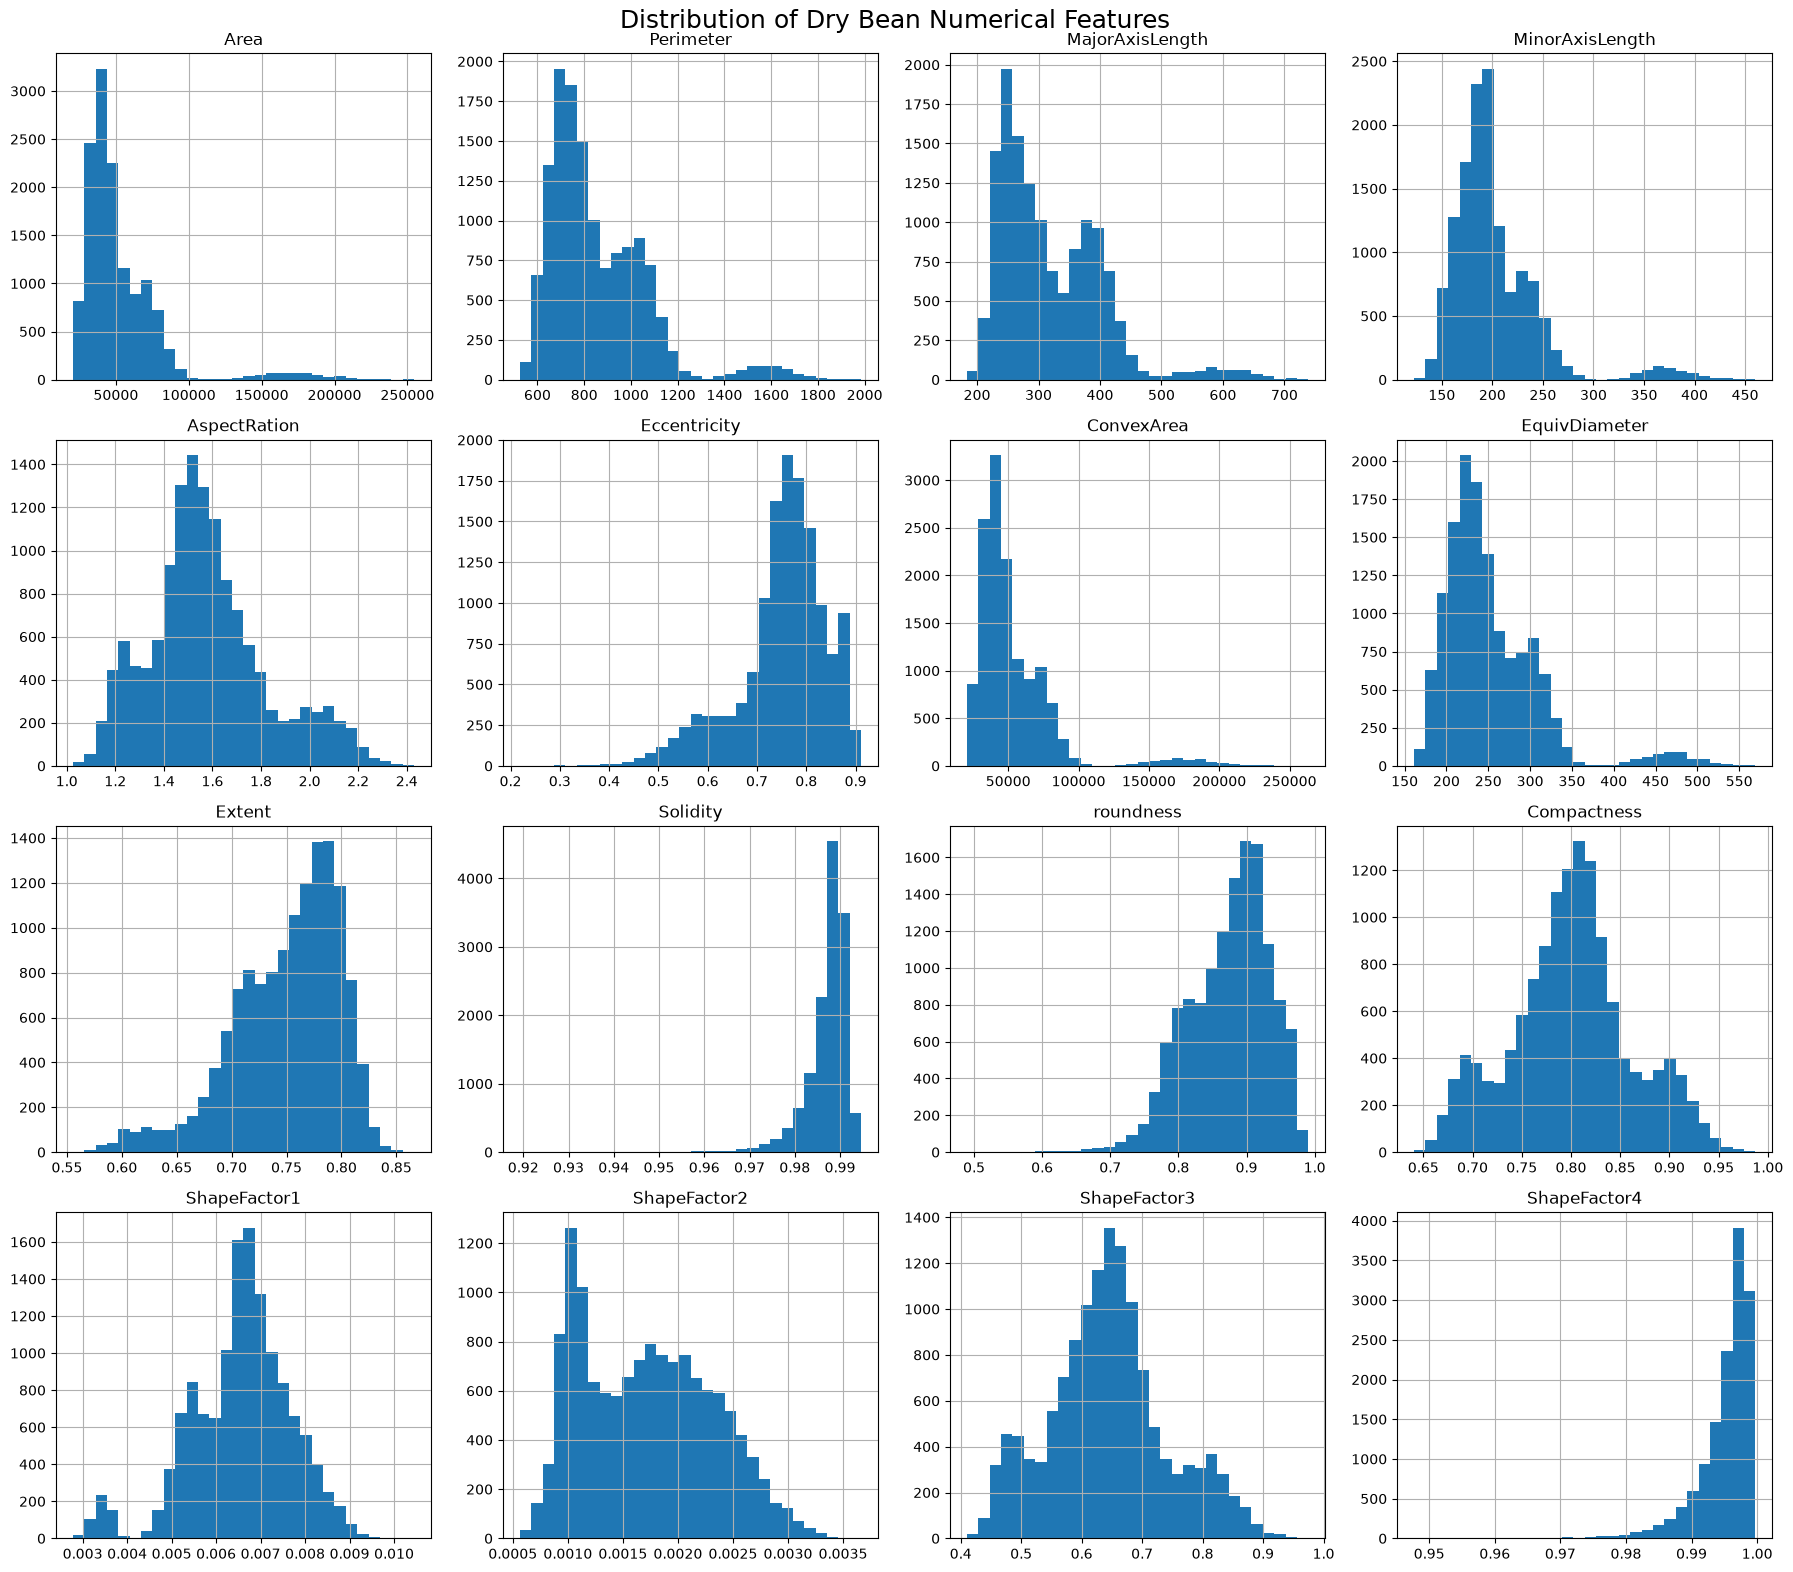


Generating boxplots...


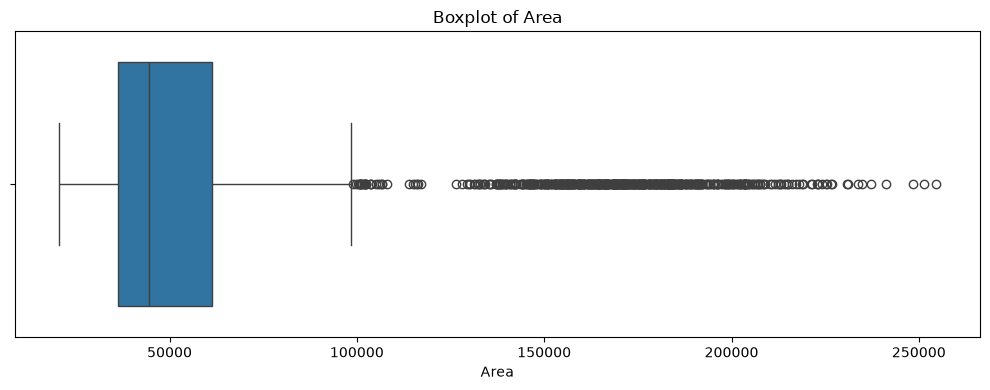

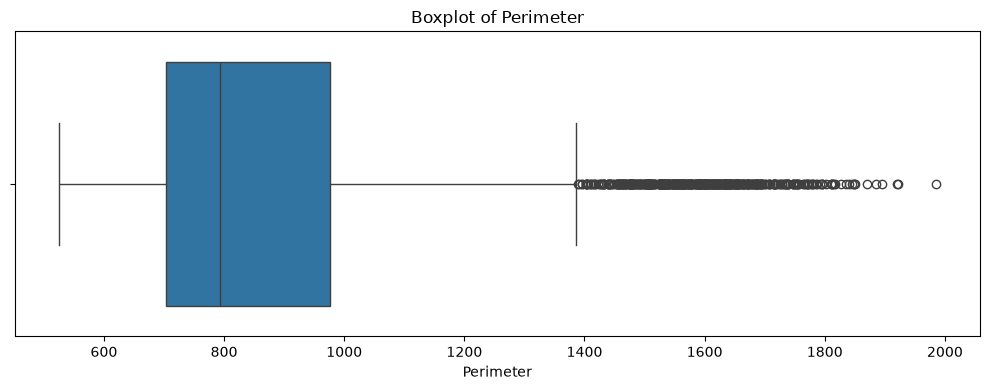

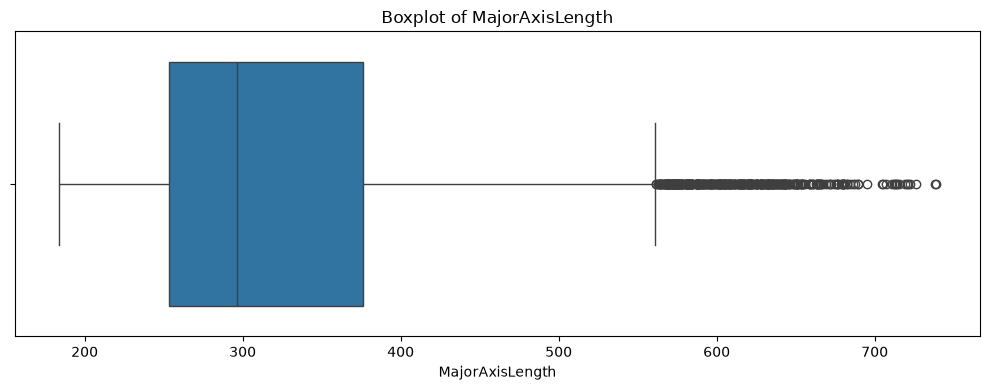

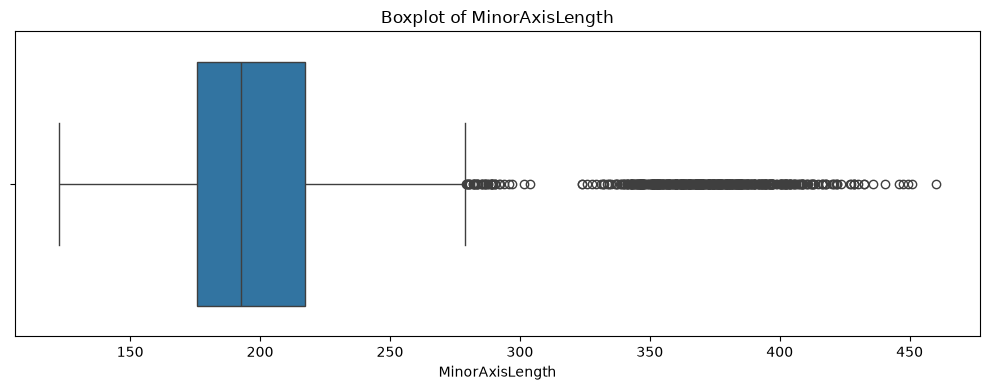

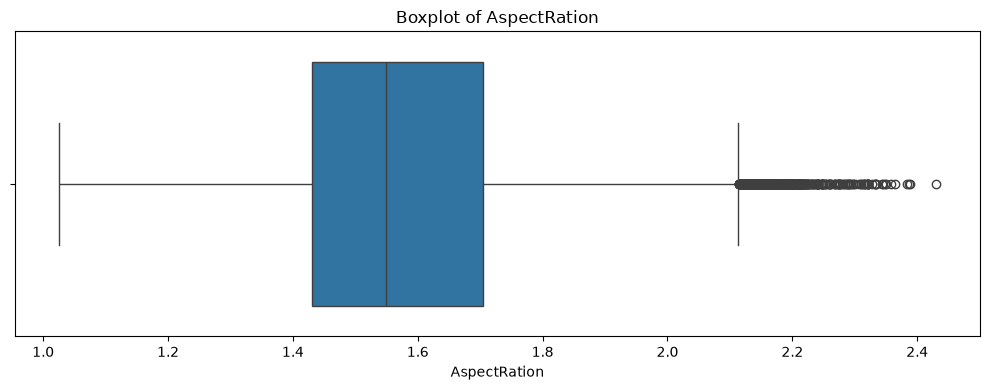

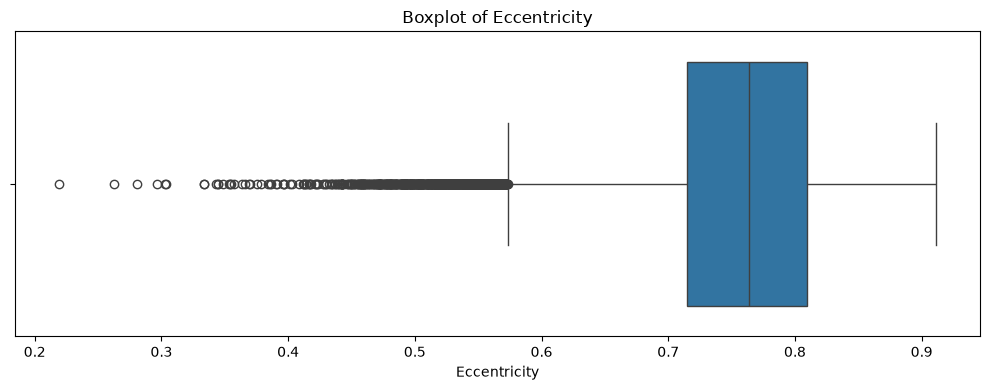

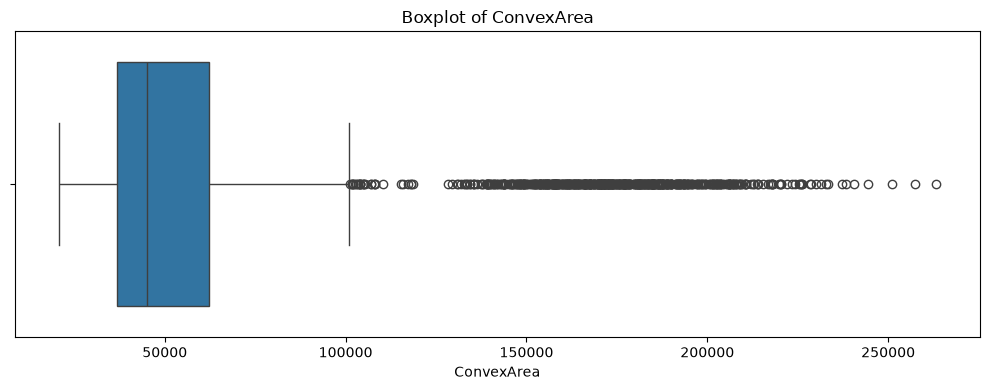

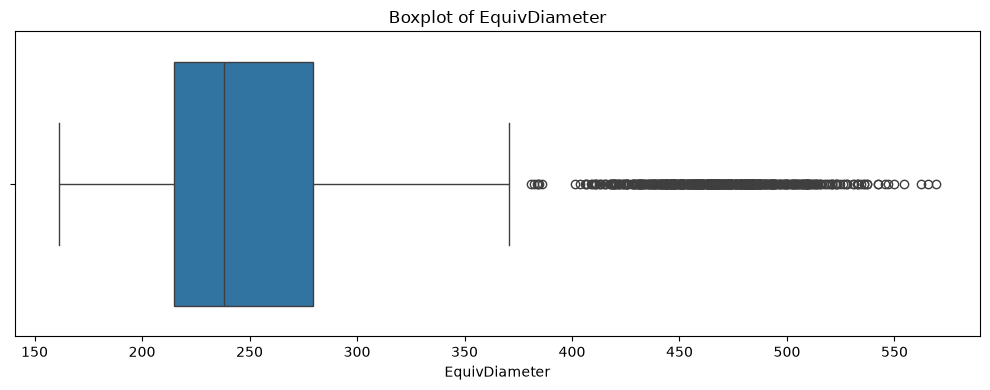

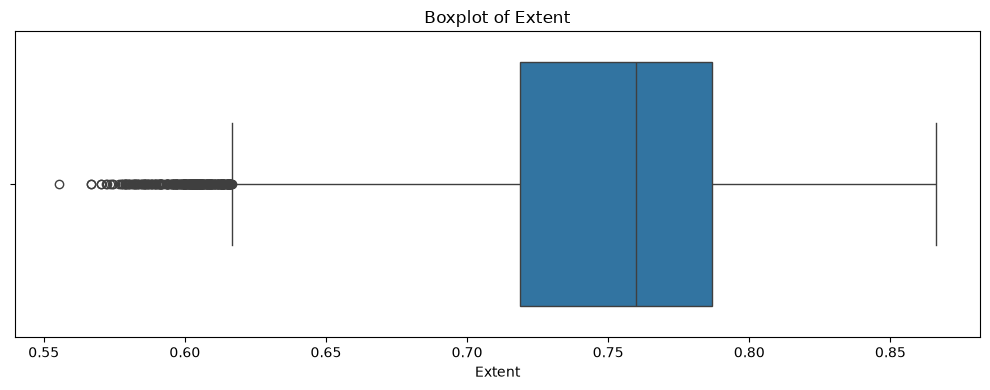

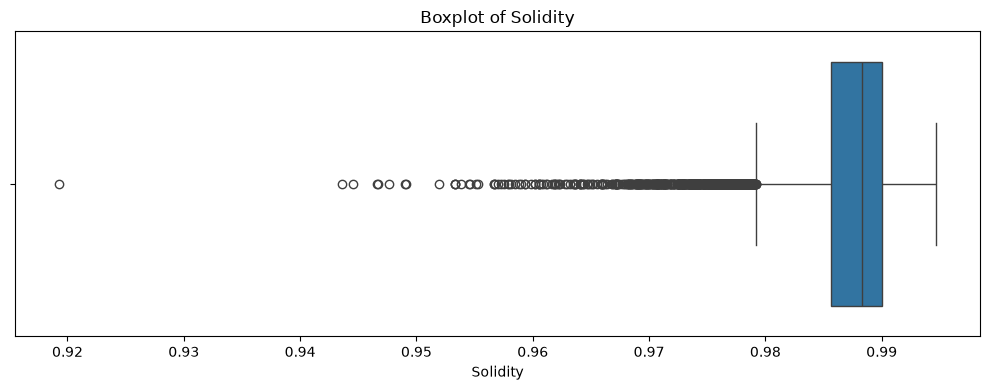

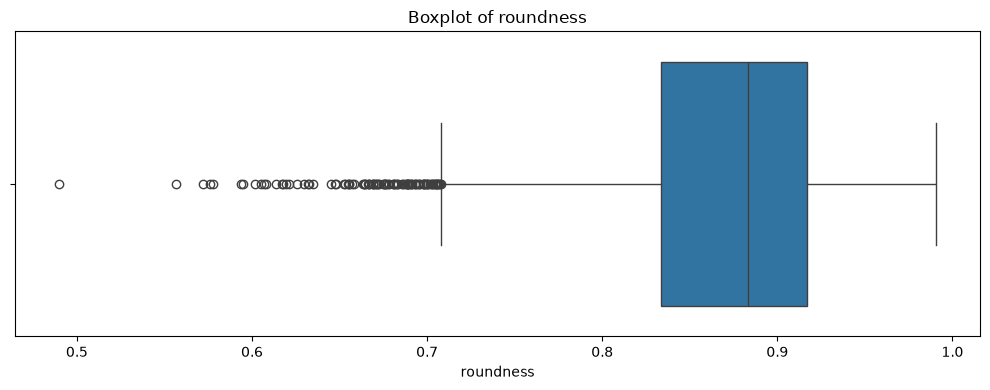

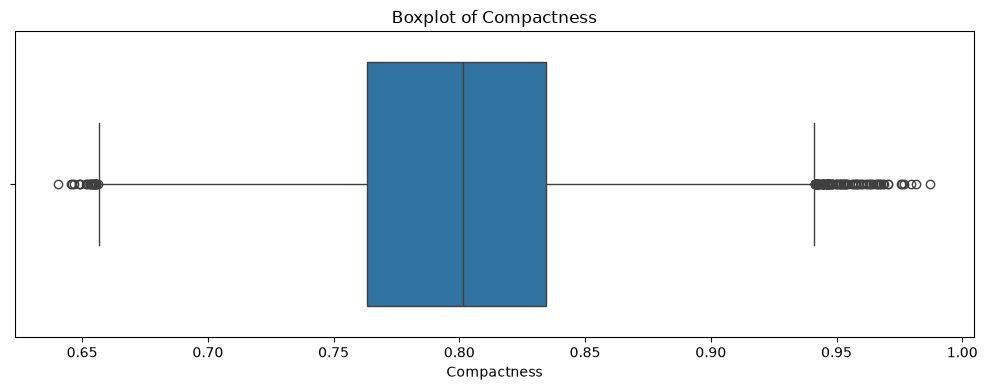

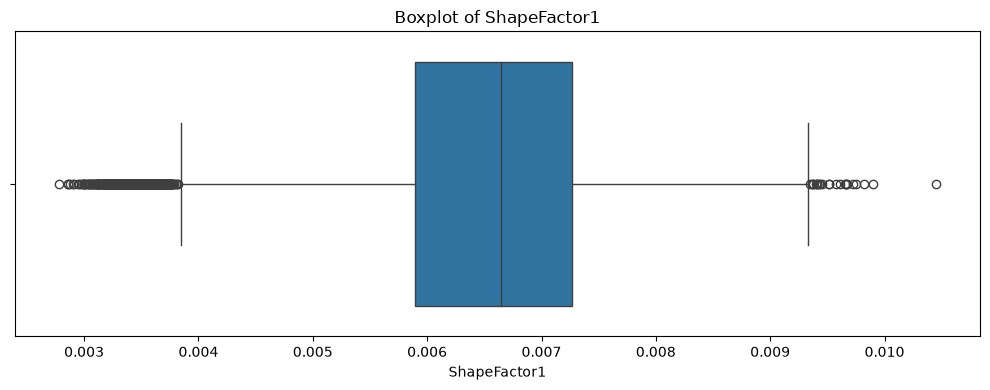

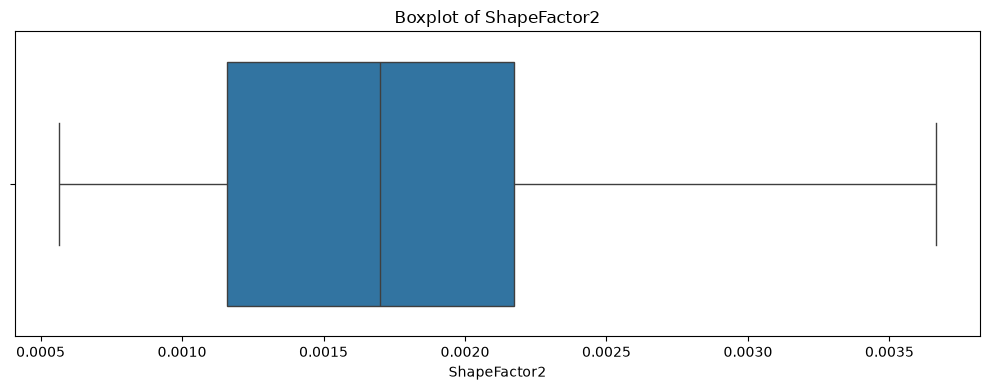

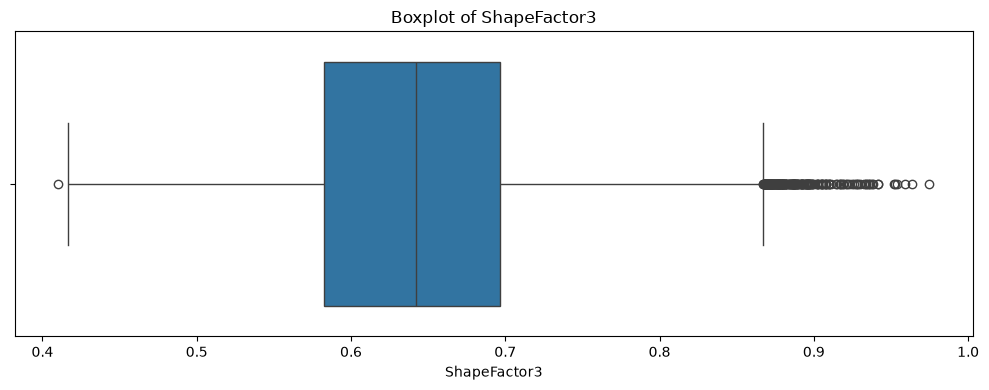

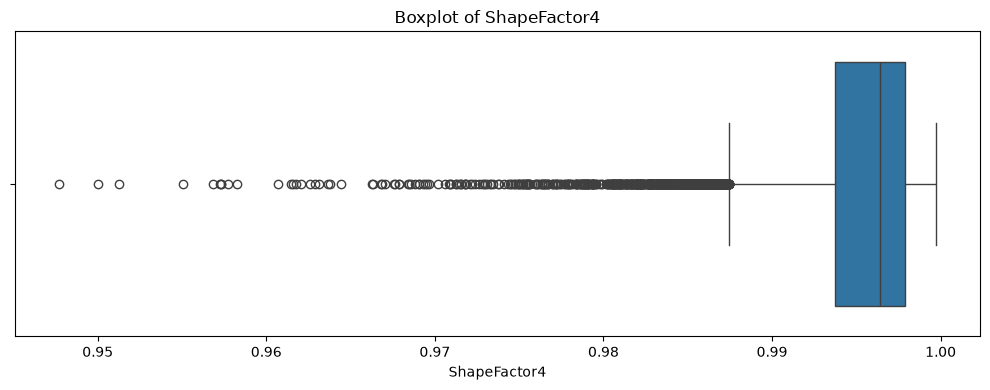


CORRELATION MATRIX


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Area,1.000000,0.966908,0.932623,0.952041,0.243698,0.268580,0.999940,0.984998,0.054648,-0.197333,-0.359068,-0.269797,-0.848390,-0.641208,-0.273754,-0.358019
Perimeter,0.966908,1.000000,0.977561,0.914336,0.386097,0.391062,0.967871,0.991453,-0.020620,-0.304662,-0.548336,-0.407426,-0.865756,-0.768590,-0.408888,-0.431215
MajorAxisLength,0.932623,0.977561,1.000000,0.828360,0.550075,0.541011,0.933392,0.962271,-0.077287,-0.284857,-0.595710,-0.567902,-0.775840,-0.859401,-0.567607,-0.484464
MinorAxisLength,0.952041,0.914336,0.828360,1.000000,-0.005354,0.022391,0.951780,0.949214,0.145906,-0.156819,-0.214090,-0.018618,-0.947194,-0.475326,-0.022744,-0.266402
AspectRation,0.243698,0.386097,0.550075,-0.005354,1.000000,0.924185,0.245267,0.305237,-0.371234,-0.269110,-0.764975,-0.987644,0.020875,-0.837338,-0.978528,-0.451598
Eccentricity,0.268580,0.391062,0.541011,0.022391,0.924185,1.000000,0.270350,0.319360,-0.319678,-0.298282,-0.720138,-0.970308,0.017266,-0.859246,-0.981058,-0.450611
ConvexArea,0.999940,0.967871,0.933392,0.951780,0.245267,0.270350,1.000000,0.985255,0.052864,-0.206901,-0.363620,-0.271651,-0.848382,-0.642773,-0.275631,-0.364302
EquivDiameter,0.984998,0.991453,0.962271,0.949214,0.305237,0.319360,0.985255,1.000000,0.028762,-0.232344,-0.437189,-0.328980,-0.893403,-0.714693,-0.331594,-0.394693
Extent,0.054648,-0.020620,-0.077287,0.145906,-0.371234,-0.319678,0.052864,0.028762,1.000000,0.192268,0.344510,0.354912,-0.141525,0.237584,0.348226,0.148622
Solidity,-0.197333,-0.304662,-0.284857,-0.156819,-0.269110,-0.298282,-0.206901,-0.232344,0.192268,1.000000,0.609668,0.304802,0.154346,0.344337,0.308614,0.700150


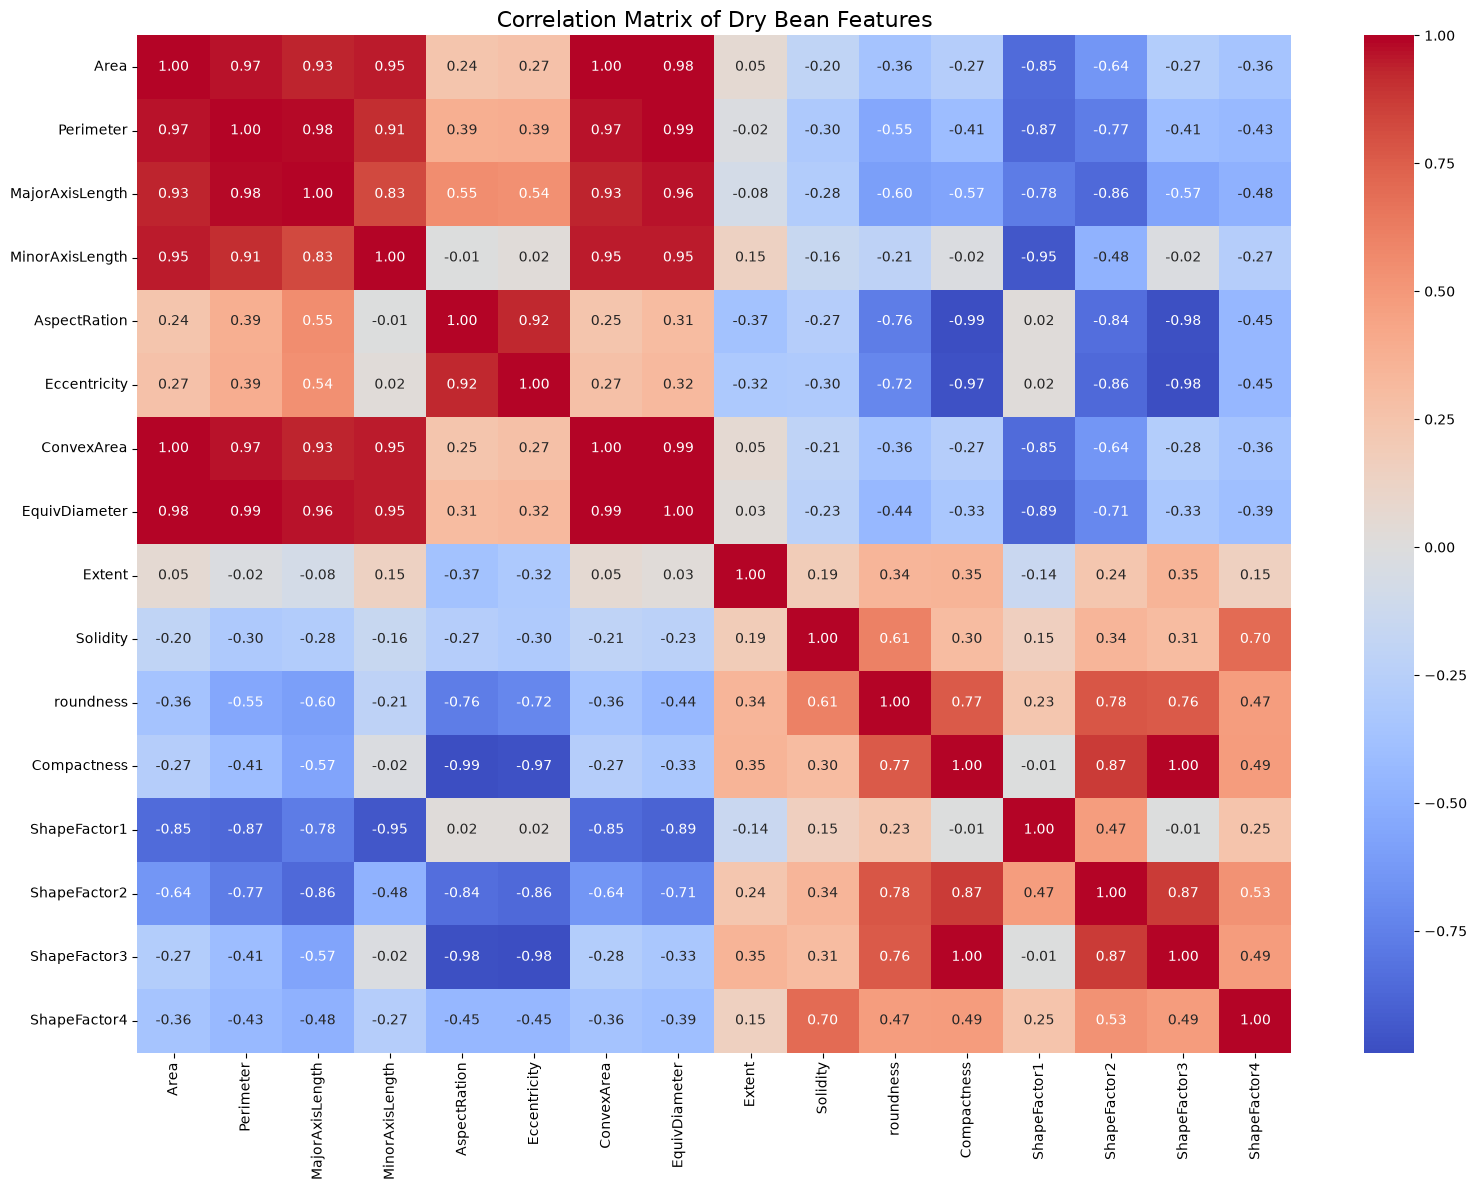


HIGHLY CORRELATED FEATURE PAIRS


,Feature 1,Feature 2,Correlation
3,Area,ConvexArea,0.999940
29,Compactness,ShapeFactor3,0.998684
9,Perimeter,EquivDiameter,0.991453
19,AspectRation,Compactness,-0.987644
25,ConvexArea,EquivDiameter,0.985255
4,Area,EquivDiameter,0.984998
24,Eccentricity,ShapeFactor3,-0.981058
21,AspectRation,ShapeFactor3,-0.978528
6,Perimeter,MajorAxisLength,0.977561
22,Eccentricity,Compactness,-0.970308



CLASS-WISE FEATURE MEANS


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Class,,,,,,,,,,,,,,,,
BARBUNYA,69804.13,1046.11,370.04,240.31,1.54,0.75,71025.73,297.31,0.75,0.98,0.80,0.81,0.01,0.0,0.65,1.00
BOMBAY,173485.06,1585.62,593.15,374.35,1.59,0.77,175813.12,468.94,0.78,0.99,0.86,0.79,0.00,0.0,0.63,0.99
CALI,75538.21,1057.63,409.50,236.37,1.73,0.81,76688.50,309.54,0.76,0.99,0.85,0.76,0.01,0.0,0.57,0.99
DERMASON,32118.71,665.21,246.56,165.66,1.49,0.74,32498.44,201.68,0.75,0.99,0.91,0.82,0.01,0.0,0.67,1.00
HOROZ,53671.73,920.11,372.69,184.20,2.03,0.87,54463.10,260.79,0.71,0.99,0.79,0.70,0.01,0.0,0.49,0.99
SEKER,39881.30,727.67,251.29,201.91,1.25,0.58,40269.57,224.95,0.77,0.99,0.94,0.90,0.01,0.0,0.81,1.00
SIRA,44729.13,796.42,299.38,190.80,1.57,0.77,45273.10,238.34,0.75,0.99,0.88,0.80,0.01,0.0,0.64,1.00



CLASS-WISE FEATURE STANDARD DEVIATION


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Class,,,,,,,,,,,,,,,,
BARBUNYA,10265.39,89.63,32.26,19.84,0.13,0.05,10445.25,22.00,0.04,0.00,0.05,0.03,0.0,0.0,0.05,0.00
BOMBAY,23327.69,115.90,53.20,23.30,0.12,0.04,23823.25,31.37,0.04,0.01,0.03,0.03,0.0,0.0,0.05,0.00
CALI,9379.88,67.62,29.51,14.67,0.09,0.02,9522.53,19.14,0.04,0.01,0.02,0.02,0.0,0.0,0.03,0.00
DERMASON,4676.13,50.47,20.66,12.55,0.10,0.04,4710.75,14.78,0.04,0.00,0.03,0.03,0.0,0.0,0.04,0.00
HOROZ,7323.24,69.86,30.16,13.45,0.14,0.02,7432.41,18.02,0.08,0.01,0.03,0.02,0.0,0.0,0.03,0.01
SEKER,4779.88,47.85,19.97,10.94,0.08,0.07,4823.87,13.29,0.02,0.00,0.03,0.03,0.0,0.0,0.05,0.00
SIRA,4546.77,44.38,20.77,9.16,0.10,0.03,4595.50,12.13,0.04,0.00,0.02,0.02,0.0,0.0,0.04,0.00



Generating class-wise feature plots...


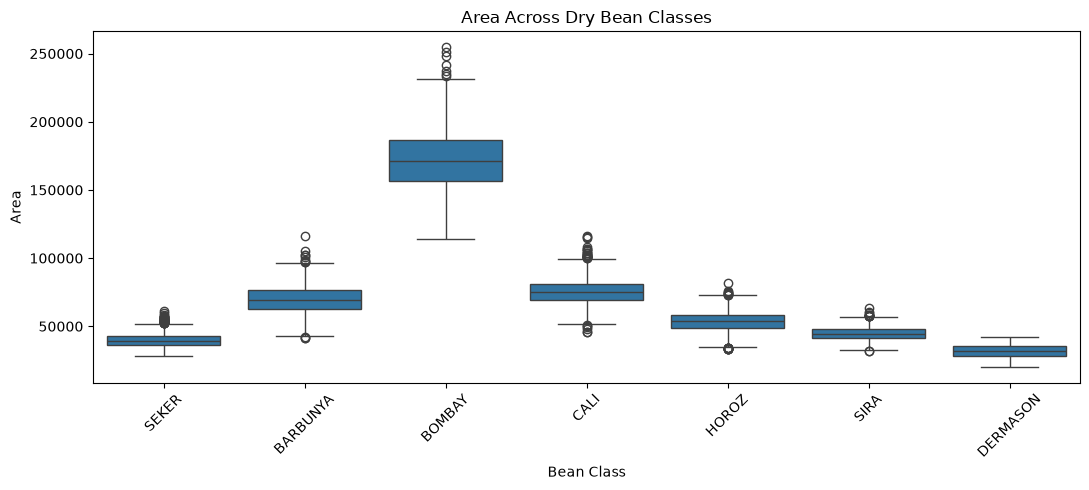

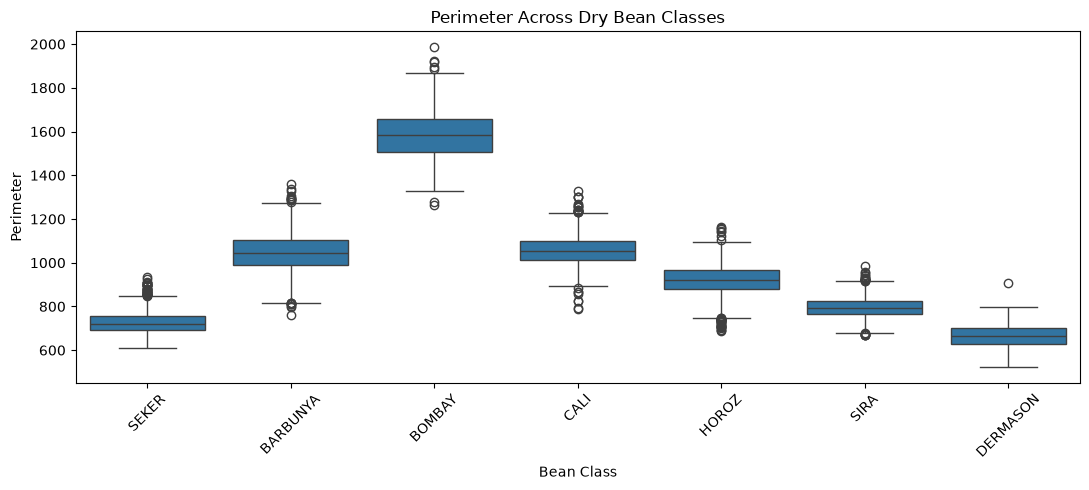

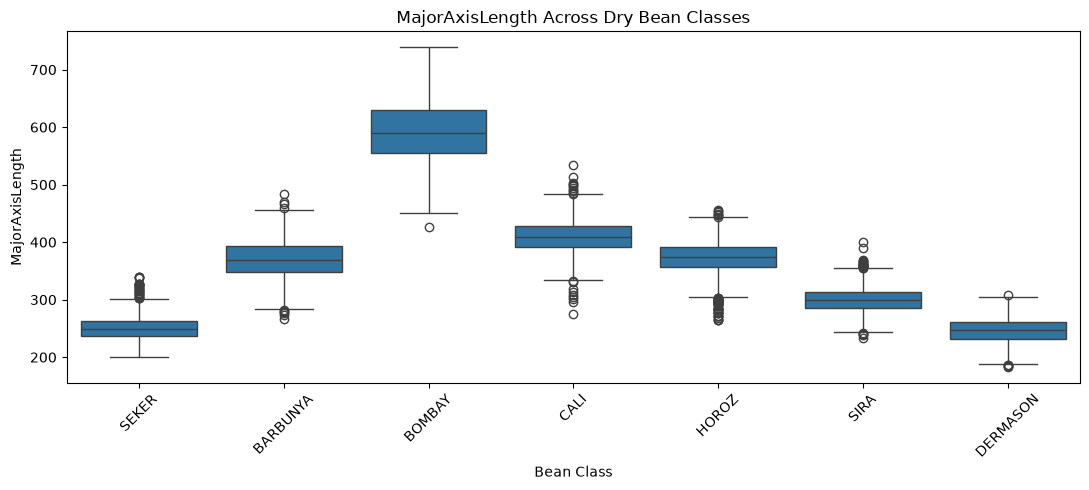

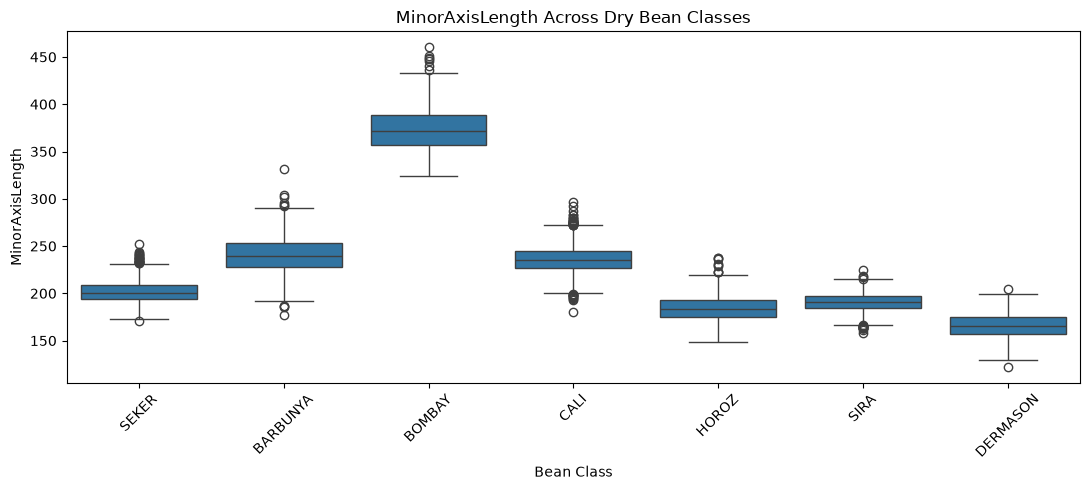

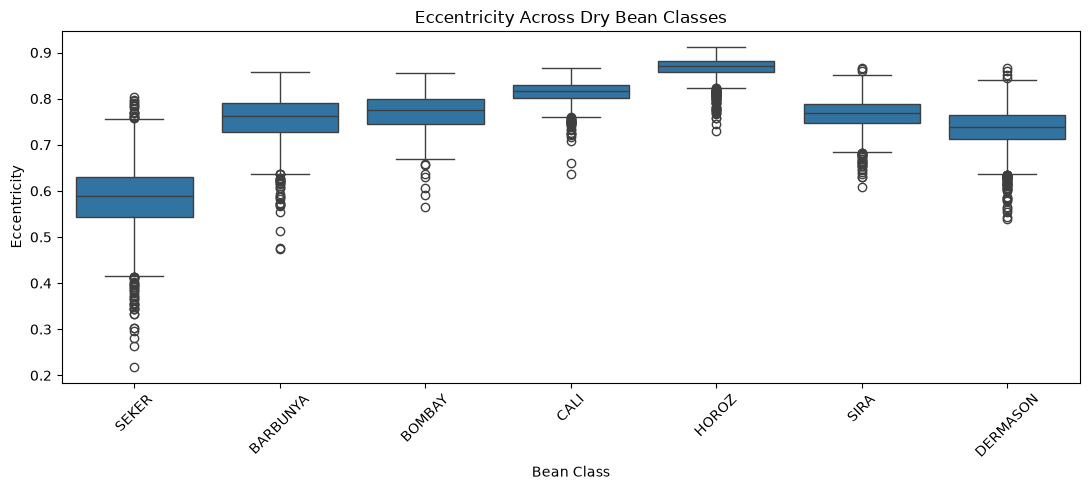

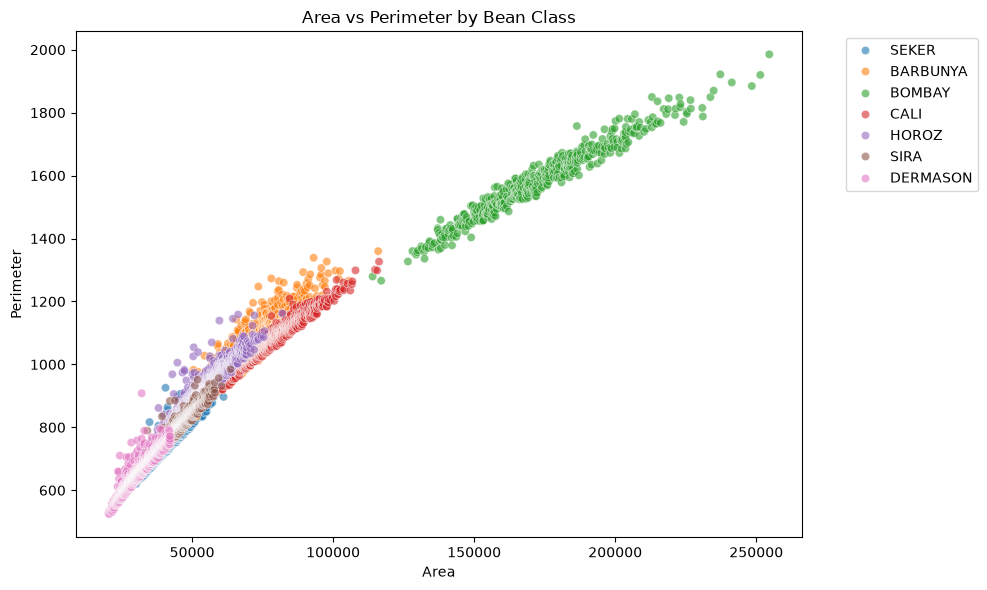

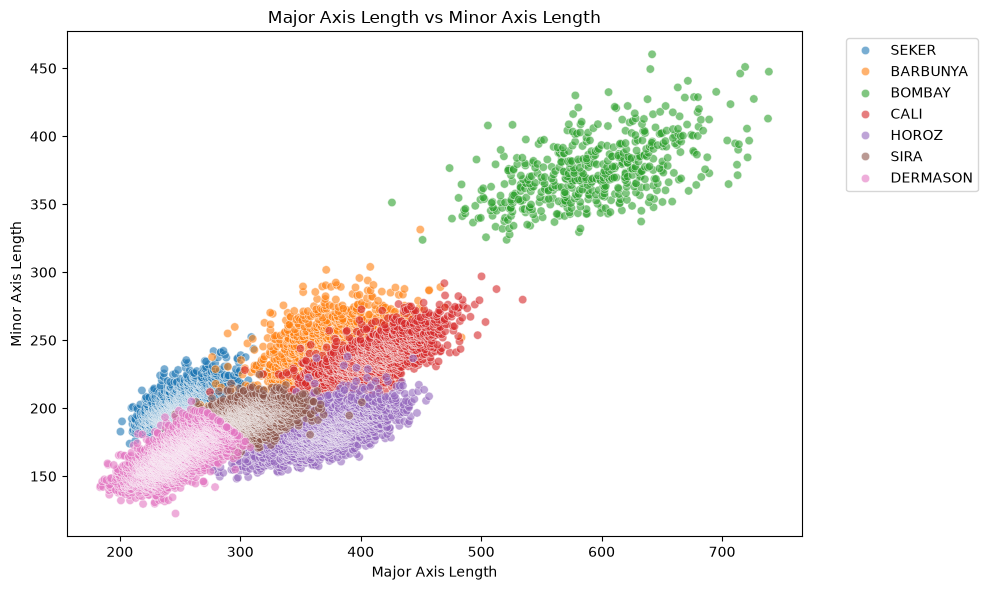


EDA COMPLETED

Dataset shape: (13543, 17)
Number of numerical features: 16
Number of bean classes: 7
Bean classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

Most common bean class: DERMASON
Least common bean class: BOMBAY

EDA analysis completed successfully.


In [12]:
# ============================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)


# ============================================================
# 1. SEPARATE NUMERICAL FEATURES
# ============================================================

numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumber of numerical features:")
print(len(numeric_features))

print("\nNumerical features:")
print(numeric_features)


# ============================================================
# 2. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(
    df[numeric_features].describe().T
)


# ============================================================
# 3. CHECK SKEWNESS
# ============================================================

print("\n" + "=" * 70)
print("FEATURE SKEWNESS")
print("=" * 70)

skewness = df[numeric_features].skew()

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df = skewness_df.sort_values(
    by="Skewness",
    key=abs,
    ascending=False
)

display(skewness_df)


# ============================================================
# 4. FEATURE DISTRIBUTIONS
# ============================================================

print("\nGenerating feature distribution plots...")

df[numeric_features].hist(
    figsize=(18, 16),
    bins=30
)

plt.suptitle(
    "Distribution of Dry Bean Numerical Features",
    fontsize=18
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. BOXPLOTS FOR OUTLIER ANALYSIS
# ============================================================

print("\nGenerating boxplots...")

for feature in numeric_features:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(
        f"Boxplot of {feature}"
    )

    plt.xlabel(feature)

    plt.tight_layout()

    plt.show()


# ============================================================
# 6. CORRELATION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

correlation_matrix = df[
    numeric_features
].corr()

display(correlation_matrix)


plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Dry Bean Features",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. HIGHLY CORRELATED FEATURE PAIRS
# ============================================================

print("\n" + "=" * 70)
print("HIGHLY CORRELATED FEATURE PAIRS")
print("=" * 70)

correlation_pairs = []

for i in range(len(numeric_features)):

    for j in range(i + 1, len(numeric_features)):

        feature1 = numeric_features[i]

        feature2 = numeric_features[j]

        correlation = correlation_matrix.loc[
            feature1,
            feature2
        ]

        if abs(correlation) >= 0.80:

            correlation_pairs.append({
                "Feature 1": feature1,
                "Feature 2": feature2,
                "Correlation": correlation
            })


high_corr_df = pd.DataFrame(
    correlation_pairs
)

if len(high_corr_df) > 0:

    high_corr_df = high_corr_df.sort_values(
        by="Correlation",
        key=abs,
        ascending=False
    )

    display(high_corr_df)

else:

    print("No feature pairs with correlation >= 0.80 found.")


# ============================================================
# 8. CLASS-WISE MEAN VALUES
# ============================================================

print("\n" + "=" * 70)
print("CLASS-WISE FEATURE MEANS")
print("=" * 70)

class_means = df.groupby(
    "Class"
)[numeric_features].mean()

display(
    class_means.round(2)
)


# ============================================================
# 9. CLASS-WISE STANDARD DEVIATION
# ============================================================

print("\n" + "=" * 70)
print("CLASS-WISE FEATURE STANDARD DEVIATION")
print("=" * 70)

class_std = df.groupby(
    "Class"
)[numeric_features].std()

display(
    class_std.round(2)
)


# ============================================================
# 10. IMPORTANT FEATURES BY CLASS
# ============================================================

selected_features = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "AspectRatio",
    "Eccentricity"
]

selected_features = [
    feature
    for feature in selected_features
    if feature in df.columns
]


# ============================================================
# 11. CLASS-WISE BOXPLOTS
# ============================================================

print("\nGenerating class-wise feature plots...")

for feature in selected_features:

    plt.figure(figsize=(11, 5))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.title(
        f"{feature} Across Dry Bean Classes"
    )

    plt.xlabel("Bean Class")

    plt.ylabel(feature)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


# ============================================================
# 12. CLASS-WISE SCATTER PLOT
# ============================================================

if (
    "Area" in df.columns
    and
    "Perimeter" in df.columns
):

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Area",
        y="Perimeter",
        hue="Class",
        alpha=0.6
    )

    plt.title(
        "Area vs Perimeter by Bean Class"
    )

    plt.xlabel("Area")

    plt.ylabel("Perimeter")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 13. CLASS-WISE SCATTER PLOT
# ============================================================

if (
    "MajorAxisLength" in df.columns
    and
    "MinorAxisLength" in df.columns
):

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="MajorAxisLength",
        y="MinorAxisLength",
        hue="Class",
        alpha=0.6
    )

    plt.title(
        "Major Axis Length vs Minor Axis Length"
    )

    plt.xlabel("Major Axis Length")

    plt.ylabel("Minor Axis Length")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 14. FINAL EDA SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EDA COMPLETED")
print("=" * 70)

print("\nDataset shape:", df.shape)

print(
    "Number of numerical features:",
    len(numeric_features)
)

print(
    "Number of bean classes:",
    df["Class"].nunique()
)

print(
    "Bean classes:",
    sorted(df["Class"].unique())
)

print(
    "\nMost common bean class:",
    df["Class"].value_counts().idxmax()
)

print(
    "Least common bean class:",
    df["Class"].value_counts().idxmin()
)

print(
    "\nEDA analysis completed successfully."
)

In [13]:
# ============================================================
# PHASE 4: DATA PREPROCESSING
# ============================================================

print("=" * 70)
print("PHASE 4: DATA PREPROCESSING")
print("=" * 70)


# ============================================================
# 1. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["Class"])

y = df["Class"]


print("\nInput features (X):")
print(X.shape)

print("\nTarget (y):")
print(y.shape)


print("\nFeature names:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")


# ============================================================
# 2. CHECK TARGET CLASSES
# ============================================================

print("\n" + "=" * 70)
print("TARGET CLASSES")
print("=" * 70)

print("\nNumber of classes:")
print(y.nunique())

print("\nClass names:")

for class_name in sorted(y.unique()):
    print("-", class_name)


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

print(
    "Total missing values:",
    X.isnull().sum().sum()
)


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("\nTraining features:")
print(X_train.shape)

print("\nTesting features:")
print(X_test.shape)

print("\nTraining target:")
print(y_train.shape)

print("\nTesting target:")
print(y_test.shape)


# ============================================================
# 5. CHECK CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

train_distribution = y_train.value_counts(
    normalize=True
) * 100

test_distribution = y_test.value_counts(
    normalize=True
) * 100


distribution_df = pd.DataFrame({

    "Training %": train_distribution,

    "Testing %": test_distribution

})

display(
    distribution_df.round(2)
)


# ============================================================
# 6. FEATURE SCALING
# ============================================================

print("\n" + "=" * 70)
print("FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


print("\nOriginal training shape:")
print(X_train.shape)

print("\nScaled training shape:")
print(X_train_scaled.shape)

print("\nOriginal testing shape:")
print(X_test.shape)

print("\nScaled testing shape:")
print(X_test_scaled.shape)


# ============================================================
# 7. CHECK SCALING
# ============================================================

scaled_mean = X_train_scaled.mean(axis=0)

scaled_std = X_train_scaled.std(axis=0)


scaling_check = pd.DataFrame({

    "Feature": X.columns,

    "Mean After Scaling": scaled_mean,

    "Std After Scaling": scaled_std

})


print("\nScaling check:")

display(
    scaling_check.round(4)
)


# ============================================================
# 8. PREPROCESSING SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PREPROCESSING COMPLETED")
print("=" * 70)

print("\nTotal samples:", len(df))

print("Number of features:", X.shape[1])

print("Number of classes:", y.nunique())

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

print("Test size: 20%")

print("Stratification: Applied")

print("Feature scaling: StandardScaler applied")

print("\nPreprocessing completed successfully!")

PHASE 4: DATA PREPROCESSING

Input features (X):
(13543, 16)

Target (y):
(13543,)

Feature names:
1. Area
2. Perimeter
3. MajorAxisLength
4. MinorAxisLength
5. AspectRation
6. Eccentricity
7. ConvexArea
8. EquivDiameter
9. Extent
10. Solidity
11. roundness
12. Compactness
13. ShapeFactor1
14. ShapeFactor2
15. ShapeFactor3
16. ShapeFactor4

TARGET CLASSES

Number of classes:
7

Class names:
- BARBUNYA
- BOMBAY
- CALI
- DERMASON
- HOROZ
- SEKER
- SIRA

MISSING VALUE CHECK
Total missing values: 0

TRAIN-TEST SPLIT

Training features:
(10834, 16)

Testing features:
(2709, 16)

Training target:
(10834,)

Testing target:
(2709,)

CLASS DISTRIBUTION


,Training %,Testing %
Class,,
DERMASON,26.19,26.17
SIRA,19.47,19.45
SEKER,14.96,14.99
HOROZ,13.73,13.73
CALI,12.04,12.03
BARBUNYA,9.76,9.78
BOMBAY,3.86,3.84



FEATURE SCALING

Original training shape:
(10834, 16)

Scaled training shape:
(10834, 16)

Original testing shape:
(2709, 16)

Scaled testing shape:
(2709, 16)

Scaling check:


,Feature,Mean After Scaling,Std After Scaling
0,Area,-0.0,1.0
1,Perimeter,0.0,1.0
2,MajorAxisLength,-0.0,1.0
3,MinorAxisLength,-0.0,1.0
4,AspectRation,0.0,1.0
5,Eccentricity,0.0,1.0
6,ConvexArea,0.0,1.0
7,EquivDiameter,0.0,1.0
8,Extent,-0.0,1.0
9,Solidity,-0.0,1.0



PREPROCESSING COMPLETED

Total samples: 13543
Number of features: 16
Number of classes: 7
Training samples: 10834
Testing samples: 2709
Test size: 20%
Stratification: Applied
Feature scaling: StandardScaler applied

Preprocessing completed successfully!


In [15]:
# ============================================================
# PHASE 5: TRAIN ALL MACHINE LEARNING MODELS
# ============================================================

print("=" * 70)
print("PHASE 5: MODEL TRAINING")
print("=" * 70)


# ============================================================
# 1. DEFINE THE SIX MODELS
# ============================================================

models = {

    # --------------------------------------------------------
    # MODEL 1: LOGISTIC REGRESSION
    # --------------------------------------------------------
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ]),


    # --------------------------------------------------------
    # MODEL 2: K-NEAREST NEIGHBORS
    # --------------------------------------------------------
    "KNN": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]),


    # --------------------------------------------------------
    # MODEL 3: DECISION TREE
    # --------------------------------------------------------
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),


    # --------------------------------------------------------
    # MODEL 4: RANDOM FOREST
    # --------------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),


    # --------------------------------------------------------
    # MODEL 5: SUPPORT VECTOR MACHINE
    # --------------------------------------------------------
    "SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]),


    # --------------------------------------------------------
    # MODEL 6: GRADIENT BOOSTING
    # --------------------------------------------------------
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}


# ============================================================
# 2. TRAIN ALL MODELS
# ============================================================

trained_models = {}

print("\nStarting model training...\n")


for name, model in models.items():

    print("-" * 60)

    print("Training:", name)

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    print("Completed:", name)


# ============================================================
# 3. DISPLAY TRAINING SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)

print("\nTotal models trained:")

print(len(trained_models))

print("\nModels:")

for number, name in enumerate(
    trained_models.keys(),
    start=1
):

    print(
        f"{number}. {name}"
    )


print("\n" + "=" * 70)
print("ALL SIX MODELS TRAINED SUCCESSFULLY!")
print("=" * 70)

PHASE 5: MODEL TRAINING

Starting model training...

------------------------------------------------------------
Training: Logistic Regression
Completed: Logistic Regression
------------------------------------------------------------
Training: KNN
Completed: KNN
------------------------------------------------------------
Training: Decision Tree
Completed: Decision Tree
------------------------------------------------------------
Training: Random Forest
Completed: Random Forest
------------------------------------------------------------
Training: SVM
Completed: SVM
------------------------------------------------------------
Training: Gradient Boosting
Completed: Gradient Boosting

TRAINING SUMMARY

Total models trained:
6

Models:
1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVM
6. Gradient Boosting

ALL SIX MODELS TRAINED SUCCESSFULLY!


PHASE 6: MODEL EVALUATION

----------------------------------------------------------------------
Evaluating: Logistic Regression
----------------------------------------------------------------------
Accuracy        : 0.9192
Macro Precision : 0.9307
Macro Recall    : 0.9300
Macro F1        : 0.9302
Weighted F1     : 0.9193

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


----------------------------------------------------

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,SVM,0.9210,0.9342,0.9317,0.9328,0.9211
1,Gradient Boosting,0.9195,0.9321,0.9288,0.9303,0.9195
2,Logistic Regression,0.9192,0.9307,0.9300,0.9302,0.9193
3,Random Forest,0.9192,0.9314,0.9289,0.9301,0.9191
4,KNN,0.9155,0.9290,0.9256,0.9270,0.9157
5,Decision Tree,0.8955,0.9094,0.9104,0.9098,0.8953


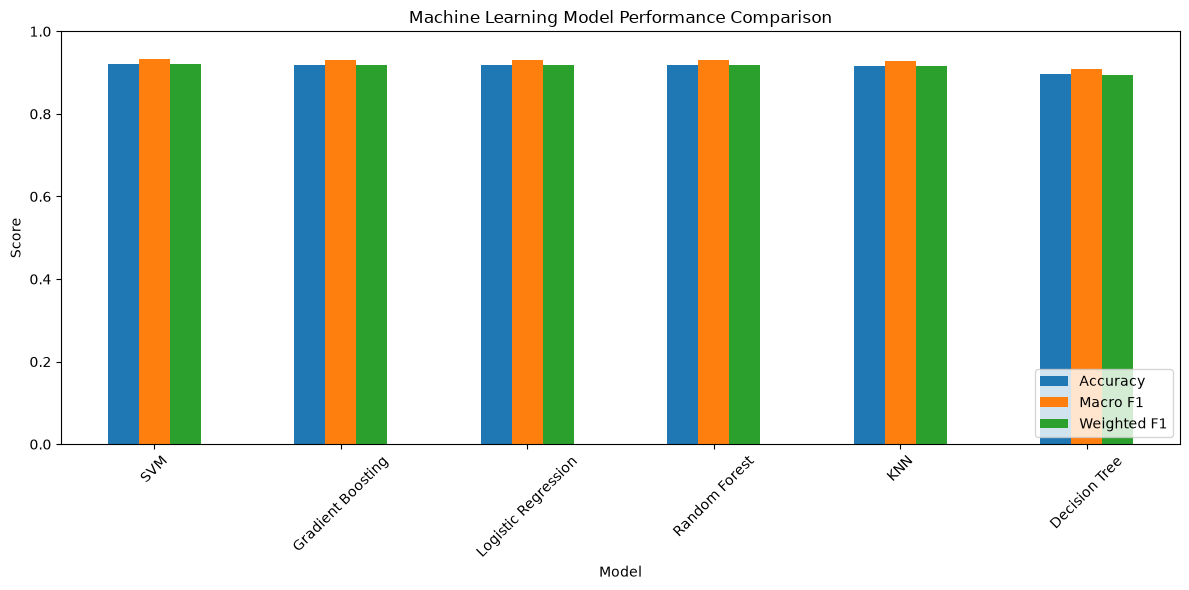


BEST MODEL

Best Model: SVM
Accuracy: 0.921
Macro F1: 0.9328
Weighted F1: 0.9211


In [16]:
# ============================================================
# PHASE 6: MODEL EVALUATION AND COMPARISON
# ============================================================

print("=" * 70)
print("PHASE 6: MODEL EVALUATION")
print("=" * 70)


# ============================================================
# STORAGE
# ============================================================

results = []

predictions = {}


# ============================================================
# EVALUATE ALL SIX MODELS
# ============================================================

for name, model in trained_models.items():

    print("\n" + "-" * 70)
    print("Evaluating:", name)
    print("-" * 70)

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    predictions[name] = y_pred


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Accuracy        : {accuracy:.4f}"
    )

    print(
        f"Macro Precision : {precision:.4f}"
    )

    print(
        f"Macro Recall    : {recall:.4f}"
    )

    print(
        f"Macro F1        : {macro_f1:.4f}"
    )

    print(
        f"Weighted F1     : {weighted_f1:.4f}"
    )


    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


# ============================================================
# CREATE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


# Sort models by Macro F1
results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)


# ============================================================
# DISPLAY MODEL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================

plot_df = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Machine Learning Model Performance Comparison"
)

plt.xlabel("Model")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=45
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()


# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_y_pred = predictions[
    best_model_name
]


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "\nBest Model:",
    best_model_name
)

print(
    "Accuracy:",
    round(
        results_df.iloc[0]["Accuracy"],
        4
    )
)

print(
    "Macro F1:",
    round(
        results_df.iloc[0]["Macro F1"],
        4
    )

)

print(
    "Weighted F1:",
    round(
        results_df.iloc[0]["Weighted F1"],
        4
    )
)

PHASE 7: CONFUSION MATRIX AND ERROR ANALYSIS

Best Model:
SVM

Best Model Performance:
Accuracy        : 0.9210
Macro Precision : 0.9342
Macro Recall    : 0.9317
Macro F1        : 0.9328
Weighted F1     : 0.9211

CLASSIFICATION REPORT FOR BEST MODEL
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


CONFUSION MATRIX
[[236   0  18   0   1   4   6]
 [  0 104   0   0   0   0   0]
 [  7   0 309   0   6   2   2]
 [  0   0   0 647   0  13  49]
 [  1   0  

,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
BARBUNYA,236,0,18,0,1,4,6
BOMBAY,0,104,0,0,0,0,0
CALI,7,0,309,0,6,2,2
DERMASON,0,0,0,647,0,13,49
HOROZ,1,0,7,5,351,0,8
SEKER,4,0,0,6,0,386,10
SIRA,3,0,1,47,6,8,462


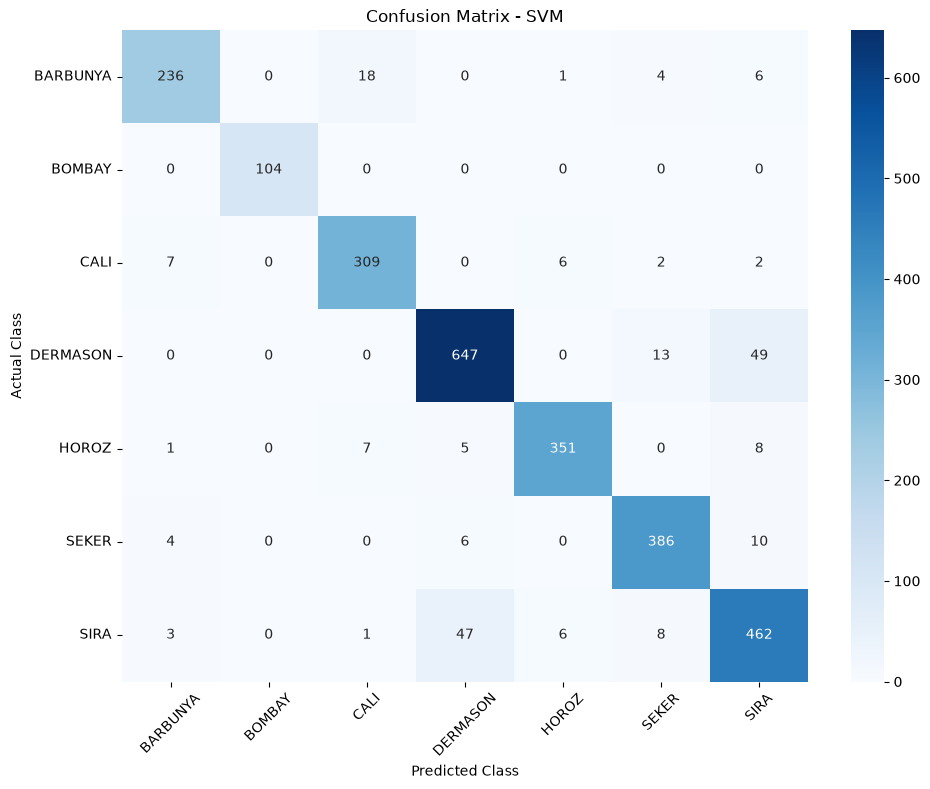


Confusion matrix SVG saved:
C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\confusion_matrix.svg

CLASS-WISE PERFORMANCE


,Class,Precision,Recall,F1-Score
0,BARBUNYA,0.9402,0.8906,0.9147
1,BOMBAY,1.0000,1.0000,1.0000
2,CALI,0.9224,0.9479,0.9349
3,DERMASON,0.9177,0.9126,0.9151
4,HOROZ,0.9643,0.9435,0.9538
5,SEKER,0.9346,0.9507,0.9426
6,SIRA,0.8603,0.8767,0.8684


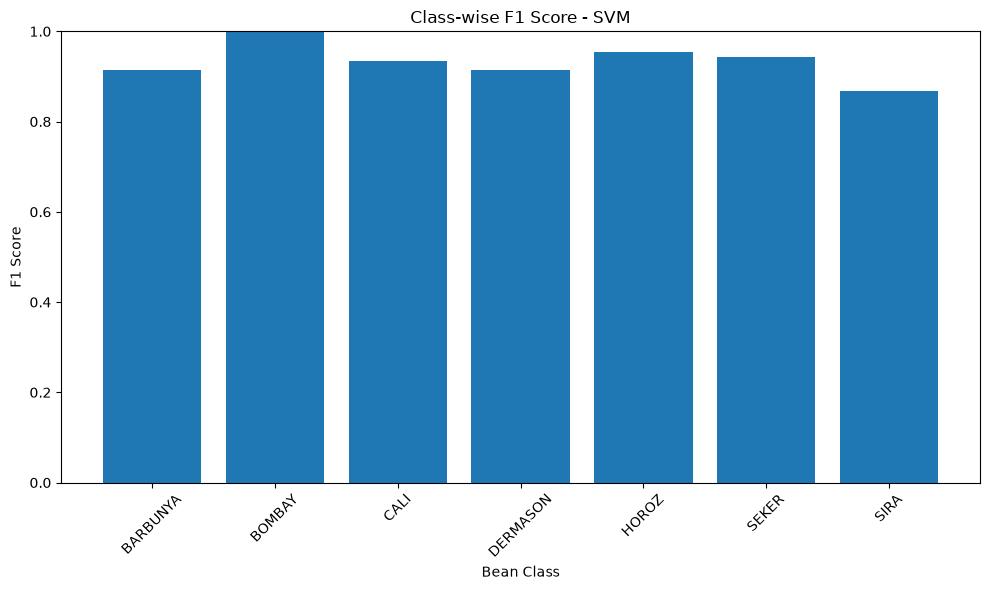


MOST FREQUENTLY CONFUSED CLASSES


,Actual Class,Predicted Class,Misclassified Count
0,DERMASON,SIRA,49
1,SIRA,DERMASON,47
2,BARBUNYA,CALI,18
3,DERMASON,SEKER,13
4,SEKER,SIRA,10
5,HOROZ,SIRA,8
6,SIRA,SEKER,8
7,CALI,BARBUNYA,7
8,HOROZ,CALI,7
9,CALI,HOROZ,6



PREDICTION SUMMARY

Total test samples: 2709
Correct predictions: 2495
Incorrect predictions: 214
Accuracy: 0.921

MISCLASSIFIED SAMPLES

Number of misclassified samples: 214


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Actual_Class,Predicted_Class,Correct
1844,46427,811.657,293.918029,202.246160,1.453269,0.725612,46974,243.131019,0.683796,0.988355,0.885596,0.827207,0.006331,0.001828,0.684271,0.994430,SEKER,SIRA,False
2008,54087,873.614,325.293118,212.060961,1.533960,0.758299,54762,262.422764,0.769287,0.987674,0.890561,0.806727,0.006014,0.001571,0.650809,0.998315,SEKER,SIRA,False
13514,41826,772.831,294.586813,181.312184,1.624749,0.788153,42287,230.769403,0.800222,0.989098,0.880009,0.783366,0.007043,0.001636,0.613663,0.997048,DERMASON,SIRA,False
2591,68024,1011.261,380.569641,230.330448,1.652277,0.796054,69648,294.297208,0.699188,0.976683,0.835883,0.773307,0.005595,0.001234,0.598004,0.988068,BARBUNYA,CALI,False
5599,41122,780.307,308.886683,170.788786,1.808589,0.833236,41692,228.819048,0.729657,0.986328,0.848698,0.740786,0.007511,0.001395,0.548764,0.992489,HOROZ,SIRA,False
3976,62493,994.395,398.877874,201.808482,1.976517,0.862568,63814,282.078994,0.758125,0.979299,0.794188,0.707181,0.006383,0.000985,0.500105,0.988467,CALI,HOROZ,False
1812,45984,790.582,293.521866,199.762426,1.469355,0.732682,46363,241.968277,0.750269,0.991825,0.924534,0.824362,0.006383,0.001818,0.679573,0.998533,SEKER,SIRA,False
8917,45645,800.090,283.742822,205.203613,1.382738,0.690636,46158,241.074717,0.727758,0.988886,0.896036,0.849624,0.006216,0.001998,0.721861,0.998145,SIRA,SEKER,False
13491,41572,766.159,274.138219,194.104485,1.412323,0.706159,42272,230.067630,0.712594,0.983441,0.889965,0.839240,0.006594,0.002018,0.704323,0.994732,DERMASON,SIRA,False
2790,71456,1005.776,374.784626,244.412588,1.533410,0.758097,72262,301.629914,0.801552,0.988846,0.887659,0.804809,0.005245,0.001357,0.647717,0.993215,BARBUNYA,CALI,False



PHASE 7 COMPLETED

Files saved:
1. C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\confusion_matrix.svg
2. C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\class_wise_metrics.xlsx
3. C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\confusion_matrix.xlsx
4. C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\misclassified_beans.xlsx


In [17]:
# ============================================================
# PHASE 7: CONFUSION MATRIX AND ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("PHASE 7: CONFUSION MATRIX AND ERROR ANALYSIS")
print("=" * 70)


# ============================================================
# 1. BEST MODEL INFORMATION
# ============================================================

print("\nBest Model:")
print(best_model_name)

print("\nBest Model Performance:")

best_accuracy = accuracy_score(
    y_test,
    best_y_pred
)

best_precision = precision_score(
    y_test,
    best_y_pred,
    average="macro",
    zero_division=0
)

best_recall = recall_score(
    y_test,
    best_y_pred,
    average="macro",
    zero_division=0
)

best_macro_f1 = f1_score(
    y_test,
    best_y_pred,
    average="macro",
    zero_division=0
)

best_weighted_f1 = f1_score(
    y_test,
    best_y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy        : {best_accuracy:.4f}")
print(f"Macro Precision : {best_precision:.4f}")
print(f"Macro Recall    : {best_recall:.4f}")
print(f"Macro F1        : {best_macro_f1:.4f}")
print(f"Weighted F1     : {best_weighted_f1:.4f}")


# ============================================================
# 2. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT FOR BEST MODEL")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_y_pred,
        zero_division=0
    )
)


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

classes = sorted(
    y.unique()
)

cm = confusion_matrix(
    y_test,
    best_y_pred,
    labels=classes
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


# ============================================================
# 4. CONFUSION MATRIX AS DATAFRAME
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

print("\nConfusion Matrix Table:")

display(cm_df)


# ============================================================
# 5. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    rotation=45
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ============================================================
# 6. SAVE CONFUSION MATRIX AS SVG
# ============================================================

svg_path = (
    data_folder /
    "confusion_matrix.svg"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    rotation=45
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.close()

print("\nConfusion matrix SVG saved:")
print(svg_path)


# ============================================================
# 7. CLASS-WISE METRICS
# ============================================================

precision_values = precision_score(
    y_test,
    best_y_pred,
    average=None,
    labels=classes,
    zero_division=0
)

recall_values = recall_score(
    y_test,
    best_y_pred,
    average=None,
    labels=classes,
    zero_division=0
)

f1_values = f1_score(
    y_test,
    best_y_pred,
    average=None,
    labels=classes,
    zero_division=0
)


class_metrics_df = pd.DataFrame({

    "Class": classes,

    "Precision": precision_values,

    "Recall": recall_values,

    "F1-Score": f1_values

})


print("\n" + "=" * 70)
print("CLASS-WISE PERFORMANCE")
print("=" * 70)

display(
    class_metrics_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)


# ============================================================
# 8. CLASS-WISE F1 GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    class_metrics_df["Class"],
    class_metrics_df["F1-Score"]
)

plt.title(
    f"Class-wise F1 Score - {best_model_name}"
)

plt.xlabel(
    "Bean Class"
)

plt.ylabel(
    "F1 Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. FIND MOST FREQUENTLY CONFUSED CLASSES
# ============================================================

# Make writable copy
confusion_copy = np.array(
    cm,
    copy=True
)

# Remove diagonal
np.fill_diagonal(
    confusion_copy,
    0
)


confusion_no_diagonal = pd.DataFrame(
    confusion_copy,
    index=classes,
    columns=classes
)


confused_pairs = []


for actual_class in classes:

    for predicted_class in classes:

        if actual_class != predicted_class:

            count = confusion_no_diagonal.loc[
                actual_class,
                predicted_class
            ]

            if count > 0:

                confused_pairs.append({

                    "Actual Class": actual_class,

                    "Predicted Class": predicted_class,

                    "Misclassified Count": int(count)

                })


confused_pairs_df = pd.DataFrame(
    confused_pairs
)


if len(confused_pairs_df) > 0:

    confused_pairs_df = confused_pairs_df.sort_values(
        by="Misclassified Count",
        ascending=False
    ).reset_index(drop=True)


print("\n" + "=" * 70)
print("MOST FREQUENTLY CONFUSED CLASSES")
print("=" * 70)

display(
    confused_pairs_df.head(10)
)


# ============================================================
# 10. TOTAL CORRECT AND INCORRECT PREDICTIONS
# ============================================================

correct_predictions = np.sum(
    np.array(y_test) ==
    np.array(best_y_pred)
)

incorrect_predictions = len(y_test) - correct_predictions


print("\n" + "=" * 70)
print("PREDICTION SUMMARY")
print("=" * 70)

print(
    "\nTotal test samples:",
    len(y_test)
)

print(
    "Correct predictions:",
    correct_predictions
)

print(
    "Incorrect predictions:",
    incorrect_predictions
)

print(
    "Accuracy:",
    round(
        correct_predictions / len(y_test),
        4
    )
)


# ============================================================
# 11. CREATE MISCLASSIFIED DATASET
# ============================================================

misclassified = X_test.copy()

misclassified["Actual_Class"] = (
    y_test.values
)

misclassified["Predicted_Class"] = (
    best_y_pred
)

misclassified["Correct"] = (
    misclassified["Actual_Class"]
    ==
    misclassified["Predicted_Class"]
)


misclassified = misclassified[
    misclassified["Correct"] == False
]


print("\n" + "=" * 70)
print("MISCLASSIFIED SAMPLES")
print("=" * 70)

print(
    "\nNumber of misclassified samples:",
    len(misclassified)
)

display(
    misclassified.head(20)
)


# ============================================================
# 12. SAVE CLASS-WISE METRICS
# ============================================================

class_metrics_path = (
    data_folder /
    "class_wise_metrics.xlsx"
)

class_metrics_df.to_excel(
    class_metrics_path,
    index=False
)


# ============================================================
# 13. SAVE CONFUSION MATRIX
# ============================================================

confusion_matrix_path = (
    data_folder /
    "confusion_matrix.xlsx"
)

cm_df.to_excel(
    confusion_matrix_path
)


# ============================================================
# 14. SAVE MISCLASSIFIED DATA
# ============================================================

misclassified_path = (
    data_folder /
    "misclassified_beans.xlsx"
)

misclassified.to_excel(
    misclassified_path,
    index=False
)


print("\n" + "=" * 70)
print("PHASE 7 COMPLETED")
print("=" * 70)

print("\nFiles saved:")

print(
    "1.",
    svg_path
)

print(
    "2.",
    class_metrics_path
)

print(
    "3.",
    confusion_matrix_path
)

print(
    "4.",
    misclassified_path
)

In [18]:
# ============================================================
# PHASE 8: FINAL MODEL, PREDICTION SYSTEM AND OUTPUT FILES
# ============================================================

print("=" * 70)
print("PHASE 8: FINAL MODEL AND PREDICTION SYSTEM")
print("=" * 70)


# ============================================================
# 1. SAVE THE BEST MODEL
# ============================================================

model_path = (
    data_folder /
    "best_dry_bean_model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("\nBest model:")
print(best_model_name)

print("\nModel saved successfully:")
print(model_path)


# ============================================================
# 2. CREATE FINAL PREDICTION OUTPUT
# ============================================================

prediction_output = X_test.copy()

prediction_output["Actual_Class"] = (
    y_test.values
)

prediction_output["Predicted_Class"] = (
    best_y_pred
)

prediction_output["Correct"] = (
    prediction_output["Actual_Class"]
    ==
    prediction_output["Predicted_Class"]
)


# ============================================================
# 3. ADD PREDICTION PROBABILITIES
# ============================================================

if hasattr(best_model, "predict_proba"):

    probabilities = best_model.predict_proba(
        X_test
    )

    model_classes = best_model.classes_

    for i, class_name in enumerate(
        model_classes
    ):

        prediction_output[
            f"Probability_{class_name}"
        ] = probabilities[:, i]


# ============================================================
# 4. SAVE PREDICTION RESULTS TO EXCEL
# ============================================================

prediction_path = (
    data_folder /
    "dry_bean_predictions.xlsx"
)

prediction_output.to_excel(
    prediction_path,
    index=False
)

print("\nPrediction results saved:")
print(prediction_path)


# ============================================================
# 5. SAVE MODEL COMPARISON
# ============================================================

comparison_path = (
    data_folder /
    "model_comparison.xlsx"
)

results_df.to_excel(
    comparison_path,
    index=False
)

print("\nModel comparison saved:")
print(comparison_path)


# ============================================================
# 6. DISPLAY SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

display(
    prediction_output.head(10)
)


# ============================================================
# 7. NEW BEAN PREDICTION FUNCTION
# ============================================================

def predict_dry_bean(
    bean_values
):

    # Convert input to DataFrame
    input_data = pd.DataFrame(
        [bean_values],
        columns=X.columns
    )

    # Prediction
    predicted_class = best_model.predict(
        input_data
    )[0]

    print("\n" + "=" * 60)
    print("DRY BEAN PREDICTION")
    print("=" * 60)

    print(
        "\nPredicted Bean Class:",
        predicted_class
    )


    # Probability
    if hasattr(
        best_model,
        "predict_proba"
    ):

        probabilities = (
            best_model.predict_proba(
                input_data
            )[0]
        )

        probability_table = pd.DataFrame({

            "Bean Class":
                best_model.classes_,

            "Probability":
                probabilities

        })

        probability_table[
            "Probability (%)"
        ] = (
            probability_table[
                "Probability"
            ] * 100
        ).round(2)


        probability_table = (
            probability_table
            .sort_values(
                by="Probability",
                ascending=False
            )
            .reset_index(drop=True)
        )


        print(
            "\nPrediction Probabilities:"
        )

        display(
            probability_table[
                [
                    "Bean Class",
                    "Probability (%)"
                ]
            ]
        )

    return predicted_class


# ============================================================
# 8. TEST THE PREDICTION FUNCTION
# ============================================================

# Take the first real sample from the dataset
test_sample = X.iloc[0].tolist()

print("\nTesting prediction function")
print("using the first dataset sample...")

predicted_result = predict_dry_bean(
    test_sample
)


# ============================================================
# 9. SHOW ACTUAL CLASS
# ============================================================

actual_result = y.iloc[0]

print(
    "\nActual Bean Class:",
    actual_result
)

print(
    "Predicted Bean Class:",
    predicted_result
)


if actual_result == predicted_result:

    print(
        "\nResult: CORRECT PREDICTION"
    )

else:

    print(
        "\nResult: INCORRECT PREDICTION"
    )


# ============================================================
# 10. FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DRY BEAN CLASSIFICATION PROJECT COMPLETED")
print("=" * 70)

print("\nDataset samples:", len(df))

print(
    "Number of features:",
    X.shape[1]
)

print(
    "Number of classes:",
    y.nunique()
)

print(
    "Best model:",
    best_model_name
)

print(
    "Best accuracy:",
    round(
        best_accuracy,
        4
    )
)

print(
    "Best Macro F1:",
    round(
        best_macro_f1,
        4
    )
)

print("\nOutput files created:")

print(
    "1. Dry_Bean_Cleaned.xlsx"
)

print(
    "2. model_comparison.xlsx"
)

print(
    "3. dry_bean_predictions.xlsx"
)

print(
    "4. class_wise_metrics.xlsx"
)

print(
    "5. confusion_matrix.xlsx"
)

print(
    "6. confusion_matrix.svg"
)

print(
    "7. misclassified_beans.xlsx"
)

print(
    "8. best_dry_bean_model.pkl"
)

print("\nAll major project components completed!")

PHASE 8: FINAL MODEL AND PREDICTION SYSTEM

Best model:
SVM

Model saved successfully:
C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\best_dry_bean_model.pkl

Prediction results saved:
C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\dry_bean_predictions.xlsx

Model comparison saved:
C:\Users\spand\Desktop\mini projects\dry bean project\data set\DryBeanDataset\model_comparison.xlsx

SAMPLE PREDICTIONS


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,...,Actual_Class,Predicted_Class,Correct,Probability_BARBUNYA,Probability_BOMBAY,Probability_CALI,Probability_DERMASON,Probability_HOROZ,Probability_SEKER,Probability_SIRA
1223,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,...,SEKER,SEKER,True,0.000257,6.041180e-05,1.911043e-04,4.048331e-04,0.000247,0.998437,0.000402
11769,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,...,DERMASON,DERMASON,True,0.000008,5.143884e-06,5.197891e-06,9.952846e-01,0.000505,0.000074,0.004118
12059,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,...,DERMASON,DERMASON,True,0.000049,4.537596e-05,5.206889e-05,9.707708e-01,0.001110,0.000431,0.027542
7126,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,...,HOROZ,HOROZ,True,0.000123,1.448936e-04,9.183330e-04,4.642109e-05,0.997985,0.000498,0.000285
638,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,...,SEKER,SEKER,True,0.000063,1.017237e-04,9.757768e-05,4.476712e-03,0.000353,0.994165,0.000742
13211,38811,726.395,268.152340,184.902092,1.450240,0.724246,39206,222.296424,0.791657,0.989925,...,DERMASON,DERMASON,True,0.000522,9.176853e-05,4.473310e-04,6.679067e-01,0.002694,0.009029,0.319310
12549,35072,693.453,254.363667,176.252147,1.443181,0.721020,35397,211.317433,0.802214,0.990818,...,DERMASON,DERMASON,True,0.000148,7.768169e-05,1.387526e-04,9.299664e-01,0.001829,0.001279,0.066561
10682,27680,608.736,224.333880,157.289337,1.426250,0.713024,27937,187.731912,0.753341,0.990801,...,DERMASON,DERMASON,True,0.000001,9.454239e-07,8.727188e-07,9.988197e-01,0.000677,0.000072,0.000428
2639,68770,1032.496,353.782883,248.615876,1.423010,0.711451,69908,295.906545,0.755051,0.983721,...,BARBUNYA,BARBUNYA,True,0.999808,2.199831e-05,1.279718e-04,7.915084e-07,0.000005,0.000033,0.000003
11764,31878,667.718,254.704323,159.710474,1.594788,0.778985,32212,201.465457,0.757827,0.989631,...,DERMASON,DERMASON,True,0.000003,2.178940e-06,2.223278e-06,9.969013e-01,0.000279,0.000026,0.002786



Testing prediction function
using the first dataset sample...

DRY BEAN PREDICTION

Predicted Bean Class: SEKER

Prediction Probabilities:


,Bean Class,Probability (%)
0,SEKER,78.57
1,DERMASON,20.45
2,HOROZ,0.43
3,SIRA,0.34
4,CALI,0.10
5,BARBUNYA,0.07
6,BOMBAY,0.04



Actual Bean Class: SEKER
Predicted Bean Class: SEKER

Result: CORRECT PREDICTION

DRY BEAN CLASSIFICATION PROJECT COMPLETED

Dataset samples: 13543
Number of features: 16
Number of classes: 7
Best model: SVM
Best accuracy: 0.921
Best Macro F1: 0.9328

Output files created:
1. Dry_Bean_Cleaned.xlsx
2. model_comparison.xlsx
3. dry_bean_predictions.xlsx
4. class_wise_metrics.xlsx
5. confusion_matrix.xlsx
6. confusion_matrix.svg
7. misclassified_beans.xlsx
8. best_dry_bean_model.pkl

All major project components completed!
